# Load Library

In [2]:
# Core Libraries
import cudf  # GPU-accelerated dataframe
import cupy as cp  # GPU-accelerated numerical computing
import numpy as np  # Numerical computing
import pandas as pd  # Fallback for CPU operations
import seaborn as sns

# Data Processing
from cuml.preprocessing import MinMaxScaler  # GPU-accelerated scaling
from sklearn.model_selection import train_test_split  # Fallback for data splitting

# Machine Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Evaluation Metrics
from cuml.metrics import regression
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Utilities
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Print library versions
print(f"cuDF Version: {cudf.__version__}")
print(f"CuPy Version: {cp.__version__}")
print(f"TensorFlow Version: {tf.__version__}")

# GPU Check
from numba import cuda

if cuda.is_available():
    print("\nGPU Detected:")
    device = cuda.get_current_device()
    print(f"Device Name: {device.name}") 
else:
    print("Warning: No GPU detected - Falling back to CPU mode")

2025-07-21 11:35:54.268309: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-21 11:35:54.568304: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-07-21 11:35:54.673943: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-07-21 11:35:54.726493: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-07-21 11:35:55.931033: I tensorflow/core/platform/cpu_feature_guar

cuDF Version: 24.10.01
CuPy Version: 13.3.0
TensorFlow Version: 2.17.0

GPU Detected:
Device Name: b'NVIDIA GeForce RTX 4050 Laptop GPU'


# Load Dataset

In [3]:
def load_datasets():
    """
    Memuat dataset Harga.csv dan Triwulan.csv dengan cudf.
    Mengembalikan tuple (harga_df, triwulan_df).
    """
    try:
        # Load Harga.csv (data harian)
        harga_df = cudf.read_csv('/home/rna_13/ModelPredict/harga.csv', parse_dates=['Tanggal'], skipinitialspace=True)
        
        # Load Triwulan.csv (data produksi)
        triwulan_df = cudf.read_csv('/home/rna_13/ModelPredict/produksi.csv', skipinitialspace=True)
        
        # Validasi keberadaan kolom penting
        required_harga_cols = {'Komoditi', 'Tanggal', ' Harga Petani ', ' Harga Pengecer '}
        required_triwulan_cols = {'Komoditi', 'tahun', 'triwulan', 'Luas Panen', 'Produktivitas', 'Produksi'}
        
        assert required_harga_cols.issubset(harga_df.columns), "Kolom tidak valid di Harga.csv"
        assert required_triwulan_cols.issubset(triwulan_df.columns), "Kolom tidak valid di Triwulan.csv"
        
        print("✔ Dataset berhasil dimuat")
        print(f"- Harga.csv: {len(harga_df)} baris")
        print(f"- Triwulan.csv: {len(triwulan_df)} baris")
        
        return harga_df, triwulan_df
    
    except FileNotFoundError as e:
        print(f"❌ File tidak ditemukan: {e}")
        return None, None
    except Exception as e:
        print(f"❌ Error saat memuat dataset: {e}")
        return None, None

# Contoh penggunaan
harga_df, triwulan_df = load_datasets()

if harga_df is not None:
    print("\n5 baris pertama harga.csv:")
    print(harga_df.head())

if triwulan_df is not None:
    print("\n5 baris pertama Produksi.csv:")
    print(triwulan_df.head())

✔ Dataset berhasil dimuat
- Harga.csv: 4382 baris
- Triwulan.csv: 30 baris

5 baris pertama harga.csv:
              Komoditi    Tanggal   Harga Petani    Harga Pengecer 
0  Jagung Pipil Kering 2022-01-03            4800              5000
1  Jagung Pipil Kering 2022-01-04            4800              5000
2  Jagung Pipil Kering 2022-01-05            4800              5000
3  Jagung Pipil Kering 2022-01-06            4800              5000
4  Jagung Pipil Kering 2022-01-07            4800              5000

5 baris pertama Produksi.csv:
     Komoditi  tahun  triwulan  Luas Panen  Produktivitas   Produksi
0  Padi sawah   2022         1  35685.6200      56.593625  201957.86
1  Padi sawah   2022         2  12599.0000      54.279752   68387.06
2  Padi sawah   2022         3   6888.7897      55.240632   38054.11
3  Padi sawah   2023         1  26790.3606      55.977470  149965.66
4  Padi sawah   2023         2  21687.8044      58.797478  127518.82


# Pembersihan data

In [4]:
harga_df = harga_df.rename(columns={
    ' Harga Petani ': 'Harga Petani',
    ' Harga Pengecer ': 'Harga Pengecer'
})

In [5]:
harga_df['Komoditi'].unique()

0    Jagung Pipil Kering
1           Beras Medium
2          Beras Premium
3           Kacang Hijau
Name: Komoditi, dtype: object

In [6]:
df_harga = harga_df[harga_df['Komoditi'] == 'Beras Premium']

In [7]:
df_harga['Tipe'] = 'Undefined'

In [8]:
df_harga['Periode'] = '0'

In [9]:
df_harga=df_harga.sort_values(by='Tanggal')
df_harga=df_harga.reset_index()
df_harga=df_harga.drop(columns=['index'])


In [10]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Beras Premium,2022-01-01,<NA>,<NA>,Undefined,0
1,Beras Premium,2022-01-02,<NA>,<NA>,Undefined,0
2,Beras Premium,2022-01-03,9500,10000,Undefined,0
3,Beras Premium,2022-01-04,9500,10000,Undefined,0
4,Beras Premium,2022-01-05,9500,10000,Undefined,0
...,...,...,...,...,...,...
1091,Beras Premium,2024-12-27,13000,14000,Undefined,0
1092,Beras Premium,2024-12-28,13000,14000,Undefined,0
1093,Beras Premium,2024-12-29,13000,14000,Undefined,0
1094,Beras Premium,2024-12-30,<NA>,<NA>,Undefined,0


# Feature Engineering

In [11]:
q1_2022_start = pd.to_datetime('2022-01-01')
q1_2022_end = pd.to_datetime('2022-04-30')

q2_2022_start = pd.to_datetime('2022-05-01')
q2_2022_end = pd.to_datetime('2022-08-31')

q3_2022_start = pd.to_datetime('2022-09-01')
q3_2022_end = pd.to_datetime('2022-12-31')

q1_2023_start = pd.to_datetime('2023-01-01')
q1_2023_end = pd.to_datetime('2023-04-30')

q2_2023_start = pd.to_datetime('2023-05-01')
q2_2023_end = pd.to_datetime('2023-08-31')

q3_2023_start = pd.to_datetime('2023-09-01')
q3_2023_end = pd.to_datetime('2023-12-31')

q1_2024_start = pd.to_datetime('2024-01-01')
q1_2024_end = pd.to_datetime('2024-04-30')

q2_2024_start = pd.to_datetime('2024-05-01')
q2_2024_end = pd.to_datetime('2024-08-31')

q3_2024_start = pd.to_datetime('2024-09-01')
q3_2024_end = pd.to_datetime('2024-12-31')

In [12]:
df_harga.loc[(df_harga['Tanggal'] >= q1_2022_start) & (df_harga['Tanggal'] <= q1_2022_end), 'Periode'] = 'Q1-2022'
df_harga.loc[(df_harga['Tanggal'] >= q2_2022_start) & (df_harga['Tanggal'] <= q2_2022_end), 'Periode'] = 'Q2-2022'
df_harga.loc[(df_harga['Tanggal'] >= q3_2022_start) & (df_harga['Tanggal'] <= q3_2022_end), 'Periode'] = 'Q3-2022'
df_harga.loc[(df_harga['Tanggal'] >= q1_2023_start) & (df_harga['Tanggal'] <= q1_2023_end), 'Periode'] = 'Q1-2023'
df_harga.loc[(df_harga['Tanggal'] >= q2_2023_start) & (df_harga['Tanggal'] <= q2_2023_end), 'Periode'] = 'Q2-2023'
df_harga.loc[(df_harga['Tanggal'] >= q3_2023_start) & (df_harga['Tanggal'] <= q3_2023_end), 'Periode'] = 'Q3-2023'
df_harga.loc[(df_harga['Tanggal'] >= q1_2024_start) & (df_harga['Tanggal'] <= q1_2024_end), 'Periode'] = 'Q1-2024'
df_harga.loc[(df_harga['Tanggal'] >= q2_2024_start) & (df_harga['Tanggal'] <= q2_2024_end), 'Periode'] = 'Q2-2024'
df_harga.loc[(df_harga['Tanggal'] >= q3_2024_start) & (df_harga['Tanggal'] <= q3_2024_end), 'Periode'] = 'Q3-2024'

In [13]:
triwulan_df['Tipe'] = 'Undefined'

In [14]:
triwulan_df.loc[(triwulan_df['Komoditi'] == 'Padi sawah'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi gogo'), 'Tipe'] = 'Padi sawah'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'padi total'), 'Tipe'] = 'Padi'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'jagung'), 'Tipe'] = 'Jagung'
triwulan_df.loc[(triwulan_df['Komoditi'] == 'kacang hijau'), 'Tipe'] = 'Kacang Hijau'

In [15]:
df_harga.loc[(df_harga['Komoditi'] == 'Beras Premium'), 'Tipe'] = 'Padi'

In [16]:
df_harga

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Beras Premium,2022-01-01,<NA>,<NA>,Padi,Q1-2022
1,Beras Premium,2022-01-02,<NA>,<NA>,Padi,Q1-2022
2,Beras Premium,2022-01-03,9500,10000,Padi,Q1-2022
3,Beras Premium,2022-01-04,9500,10000,Padi,Q1-2022
4,Beras Premium,2022-01-05,9500,10000,Padi,Q1-2022
...,...,...,...,...,...,...
1091,Beras Premium,2024-12-27,13000,14000,Padi,Q3-2024
1092,Beras Premium,2024-12-28,13000,14000,Padi,Q3-2024
1093,Beras Premium,2024-12-29,13000,14000,Padi,Q3-2024
1094,Beras Premium,2024-12-30,<NA>,<NA>,Padi,Q3-2024


In [17]:
triwulan_df['Periode'] = "Q" + triwulan_df['triwulan'].astype(str) + "-" + triwulan_df['tahun'].astype(str)

In [18]:
df_merged = cudf.merge(
    df_harga,
    triwulan_df,
    left_on=['Periode', 'Tipe'], # Kolom dari df_penjualan
    right_on=['Periode', 'Tipe'],       # Kolom dari df_kehadiran
    how='left'                               # Pilih jenis join sesuai kebutuhanmu
)

In [19]:
df_merged=df_merged.sort_values(by='Tanggal')
df_merged=df_merged.reset_index()
df_merged=df_merged.drop(columns=['index', 'triwulan'])
df_merged

,Komoditi_x,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,Komoditi_y,tahun,Luas Panen,Produktivitas,Produksi
0,Beras Premium,2022-01-01,<NA>,<NA>,Padi,Q1-2022,padi total,2022,38556.62,55.20358781,212846.3758
1,Beras Premium,2022-01-02,<NA>,<NA>,Padi,Q1-2022,padi total,2022,38556.62,55.20358781,212846.3758
2,Beras Premium,2022-01-03,9500,10000,Padi,Q1-2022,padi total,2022,38556.62,55.20358781,212846.3758
3,Beras Premium,2022-01-04,9500,10000,Padi,Q1-2022,padi total,2022,38556.62,55.20358781,212846.3758
4,Beras Premium,2022-01-05,9500,10000,Padi,Q1-2022,padi total,2022,38556.62,55.20358781,212846.3758
...,...,...,...,...,...,...,...,...,...,...,...
1091,Beras Premium,2024-12-27,13000,14000,Padi,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1092,Beras Premium,2024-12-28,13000,14000,Padi,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1093,Beras Premium,2024-12-29,13000,14000,Padi,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>
1094,Beras Premium,2024-12-30,<NA>,<NA>,Padi,Q3-2024,<NA>,<NA>,<NA>,<NA>,<NA>


In [20]:
df_merged=df_merged.drop(columns=['Komoditi_y'])
df_merged = df_merged.rename(columns={'Komoditi_x' : 'Komoditi'})

In [21]:
df_merged=df_merged.to_pandas()

In [22]:
df_merged

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi
0,Beras Premium,2022-01-01,NaN,NaN,Padi,Q1-2022,2022.0,38556.62,55.203588,212846.3758
1,Beras Premium,2022-01-02,NaN,NaN,Padi,Q1-2022,2022.0,38556.62,55.203588,212846.3758
2,Beras Premium,2022-01-03,9500.0,10000.0,Padi,Q1-2022,2022.0,38556.62,55.203588,212846.3758
3,Beras Premium,2022-01-04,9500.0,10000.0,Padi,Q1-2022,2022.0,38556.62,55.203588,212846.3758
4,Beras Premium,2022-01-05,9500.0,10000.0,Padi,Q1-2022,2022.0,38556.62,55.203588,212846.3758
...,...,...,...,...,...,...,...,...,...,...
1091,Beras Premium,2024-12-27,13000.0,14000.0,Padi,Q3-2024,NaN,NaN,NaN,NaN
1092,Beras Premium,2024-12-28,13000.0,14000.0,Padi,Q3-2024,NaN,NaN,NaN,NaN
1093,Beras Premium,2024-12-29,13000.0,14000.0,Padi,Q3-2024,NaN,NaN,NaN,NaN
1094,Beras Premium,2024-12-30,NaN,NaN,Padi,Q3-2024,NaN,NaN,NaN,NaN


In [23]:
df_train=df_merged[(df_merged['Tanggal'] >= '2022-01-01') & (df_merged['Tanggal'] <= '2023-12-31')].copy()

# Handling Missing Values

In [24]:
from statsmodels.tsa.seasonal import STL
import numpy as np
import pandas as pd

def stl_imputation(series, period=30):
    """
    Mengisi missing value (NaN) dalam deret waktu menggunakan dekomposisi STL.
    
    Argumen:
    series (pd.Series): Deret waktu dengan kemungkinan missing value (NaN).
    period (int): Periode musiman deret waktu (misal 30 untuk data harian bulanan).

    Mengembalikan:
    pd.Series: Deret waktu dengan missing value yang sudah diisi.
    """
    
    # Pastikan series adalah Pandas Series dan indeksnya berupa datetime
    if not isinstance(series, pd.Series):
        series = pd.Series(series)
    
    # Buat salinan seri untuk bekerja, agar tidak mengubah seri asli
    imputed_series = series.copy()
    
    # Identifikasi indeks missing values
    missing_indices = imputed_series[imputed_series.isnull()].index
    
    if missing_indices.empty:
        print("Tidak ada missing value untuk diisi.")
        return series
        
    print(f"Mengisi {len(missing_indices)} missing value menggunakan STL imputation...")

    # Langkah 1: Interpolasi awal untuk mengisi NaN sementara.
    # STL tidak bisa bekerja dengan NaN di tengah seri.
    # Interpolasi linear adalah pilihan umum untuk ini.
    temp_series = imputed_series.interpolate(method='linear', limit_direction='both')
    
    # Jika masih ada NaN di awal/akhir setelah interpolasi, isi dengan mean
    if temp_series.isnull().any():
        temp_series = temp_series.fillna(temp_series.mean())

    # Langkah 2: Dekomposisi STL
    # Pastikan period sesuai dengan data Anda (misal 30 untuk bulanan)
    stl = STL(temp_series, period=period, robust=True)
    result = stl.fit()
    
    # Langkah 3: Rekonstruksi tanpa noise (menggunakan trend + seasonal)
    reconstructed_values = result.trend + result.seasonal
    
    # Langkah 4: Isi missing value dengan nilai rekonstruksi
    # Kita hanya mengganti nilai di indeks yang tadinya NaN
    imputed_series.loc[missing_indices] = reconstructed_values.loc[missing_indices]
    
    print("Pengisian missing value selesai.")
    return imputed_series


print("DataFrame sebelum imputasi:")
print(df_train)
print("\nMissing values sebelum imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())


# Pastikan kolom 'Tanggal' adalah indeks

# Untuk satu komoditi :
df_train['Harga Petani'] = stl_imputation(df_train['Harga Petani'], period=30) # Asumsi periode mingguan
df_train['Harga Pengecer'] = stl_imputation(df_train['Harga Pengecer'], period=30)


print("\nDataFrame setelah imputasi:")
print(df_train)
print("\nMissing values setelah imputasi:")
print(df_train['Harga Petani'].isnull().sum())
print(df_train['Harga Pengecer'].isnull().sum())

DataFrame sebelum imputasi:
          Komoditi    Tanggal  Harga Petani  Harga Pengecer  Tipe  Periode  \
0    Beras Premium 2022-01-01           NaN             NaN  Padi  Q1-2022   
1    Beras Premium 2022-01-02           NaN             NaN  Padi  Q1-2022   
2    Beras Premium 2022-01-03        9500.0         10000.0  Padi  Q1-2022   
3    Beras Premium 2022-01-04        9500.0         10000.0  Padi  Q1-2022   
4    Beras Premium 2022-01-05        9500.0         10000.0  Padi  Q1-2022   
..             ...        ...           ...             ...   ...      ...   
725  Beras Premium 2023-12-27       13500.0         14600.0  Padi  Q3-2023   
726  Beras Premium 2023-12-28       13500.0         14600.0  Padi  Q3-2023   
727  Beras Premium 2023-12-29       13500.0         14600.0  Padi  Q3-2023   
728  Beras Premium 2023-12-30       13500.0         14600.0  Padi  Q3-2023   
729  Beras Premium 2023-12-31           NaN             NaN  Padi  Q3-2023   

      tahun  Luas Panen  Produktivi

In [26]:
# 1. Hari dalam sebulan (Day)
df_train['Hari'] = df_train['Tanggal'].dt.day

# 2. Bulan (Month)
df_train['Bulan'] = df_train['Tanggal'].dt.month

# 3. Tahun (Year)
df_train['Tahun'] = df_train['Tanggal'].dt.year

In [27]:
df_train=df_train.reset_index()
df_train=df_train.drop(columns=['index'])

In [28]:
df=df_train.copy()
df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Beras Premium,2022-01-01,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,1,1,2022
1,Beras Premium,2022-01-02,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,2,1,2022
2,Beras Premium,2022-01-03,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,3,1,2022
3,Beras Premium,2022-01-04,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,4,1,2022
4,Beras Premium,2022-01-05,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,5,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,Beras Premium,2023-12-27,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,27,12,2023
726,Beras Premium,2023-12-28,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,28,12,2023
727,Beras Premium,2023-12-29,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,29,12,2023
728,Beras Premium,2023-12-30,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,30,12,2023


In [29]:
df.isnull().sum()

Komoditi          0
Tanggal           0
Harga Petani      0
Harga Pengecer    0
Tipe              0
Periode           0
tahun             0
Luas Panen        0
Produktivitas     0
Produksi          0
Hari              0
Bulan             0
Tahun             0
dtype: int64

In [30]:
data_train=df[(df['Tanggal'] >= '2022-01-01') & (df['Tanggal'] <= '2023-12-31')].copy()

## membagi data train dan test

In [32]:
# Hitung indeks pembagian (80% train, 20% test)
split_idx = int(len(data_train) * 0.8)

# Bagi data
train_df = data_train.iloc[:split_idx]
test_df = data_train.iloc[split_idx:]
test_df=test_df.reset_index()
test_df=test_df.drop(columns=['index'])

# Normalisasi Data

In [33]:
scaler = MinMaxScaler()

In [34]:
kolom_scale = ['Harga Petani', 'Harga Pengecer', 'Luas Panen', 'Produktivitas', 'Produksi']
data_scaling_train = train_df[kolom_scale]
data_scaling_test = test_df[kolom_scale]

In [35]:
data_scaling_train

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi
0,9499.999998,9999.999978,38556.6200,55.203588,212846.3758
1,9499.999998,9999.999959,38556.6200,55.203588,212846.3758
2,9500.000000,10000.000000,38556.6200,55.203588,212846.3758
3,9500.000000,10000.000000,38556.6200,55.203588,212846.3758
4,9500.000000,10000.000000,38556.6200,55.203588,212846.3758
...,...,...,...,...,...
579,10700.000000,11900.000000,21687.8044,58.797478,127518.8200
580,10700.000000,11900.000000,21687.8044,58.797478,127518.8200
581,10897.914954,11923.344286,21687.8044,58.797478,127518.8200
582,10846.569856,11924.435723,21687.8044,58.797478,127518.8200


In [36]:
data_scaling_test

,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi
0,10700.000000,11900.000000,21687.8044,58.797478,127518.82
1,10700.000000,11900.000000,21687.8044,58.797478,127518.82
2,10700.000000,11900.000000,21687.8044,58.797478,127518.82
3,10700.000000,11900.000000,21687.8044,58.797478,127518.82
4,10663.755398,11927.185857,21687.8044,58.797478,127518.82
...,...,...,...,...,...
141,13500.000000,14600.000000,8101.2824,54.176608,43890.00
142,13500.000000,14600.000000,8101.2824,54.176608,43890.00
143,13500.000000,14600.000000,8101.2824,54.176608,43890.00
144,13500.000000,14600.000000,8101.2824,54.176608,43890.00


In [37]:
scaled_data_train = scaler.fit_transform(data_scaling_train.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_train = pd.DataFrame(scaled_data_train, columns=nama_kolom_scaled_baru)
scaled_train

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.000021,0.122205,1.00000,0.204491,1.000000
1,0.000021,0.122205,1.00000,0.204491,1.000000
2,0.000021,0.122205,1.00000,0.204491,1.000000
3,0.000021,0.122205,1.00000,0.204491,1.000000
4,0.000021,0.122205,1.00000,0.204491,1.000000
...,...,...,...,...,...
579,0.802294,0.982666,0.46732,1.000000,0.511834
580,0.802294,0.982666,0.46732,1.000000,0.511834
581,0.934612,0.993238,0.46732,1.000000,0.511834
582,0.900285,0.993732,0.46732,1.000000,0.511834


In [38]:
scaled_data_test = scaler.transform(data_scaling_test.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_test = pd.DataFrame(scaled_data_test, columns=nama_kolom_scaled_baru)
scaled_test

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.802294,0.982666,0.467320,1.000000,0.511834
1,0.802294,0.982666,0.467320,1.000000,0.511834
2,0.802294,0.982666,0.467320,1.000000,0.511834
3,0.802294,0.982666,0.467320,1.000000,0.511834
4,0.778062,0.994978,0.467320,1.000000,0.511834
...,...,...,...,...,...
141,2.674263,2.205426,0.038288,-0.022831,0.033388
142,2.674263,2.205426,0.038288,-0.022831,0.033388
143,2.674263,2.205426,0.038288,-0.022831,0.033388
144,2.674263,2.205426,0.038288,-0.022831,0.033388


In [39]:
train_df[nama_kolom_scaled_baru] = scaled_train
train_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,Beras Premium,2022-01-01,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,1,1,2022,0.000021,0.122205,1.00000,0.204491,1.000000
1,Beras Premium,2022-01-02,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,2,1,2022,0.000021,0.122205,1.00000,0.204491,1.000000
2,Beras Premium,2022-01-03,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,3,1,2022,0.000021,0.122205,1.00000,0.204491,1.000000
3,Beras Premium,2022-01-04,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,4,1,2022,0.000021,0.122205,1.00000,0.204491,1.000000
4,Beras Premium,2022-01-05,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,5,1,2022,0.000021,0.122205,1.00000,0.204491,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,Beras Premium,2023-08-03,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,3,8,2023,0.802294,0.982666,0.46732,1.000000,0.511834
580,Beras Premium,2023-08-04,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,4,8,2023,0.802294,0.982666,0.46732,1.000000,0.511834
581,Beras Premium,2023-08-05,10897.914954,11923.344286,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,5,8,2023,0.934612,0.993238,0.46732,1.000000,0.511834
582,Beras Premium,2023-08-06,10846.569856,11924.435723,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,6,8,2023,0.900285,0.993732,0.46732,1.000000,0.511834


In [40]:
test_df[nama_kolom_scaled_baru] = scaled_test
test_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,Beras Premium,2023-08-08,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,8,8,2023,0.802294,0.982666,0.467320,1.000000,0.511834
1,Beras Premium,2023-08-09,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,9,8,2023,0.802294,0.982666,0.467320,1.000000,0.511834
2,Beras Premium,2023-08-10,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,10,8,2023,0.802294,0.982666,0.467320,1.000000,0.511834
3,Beras Premium,2023-08-11,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,11,8,2023,0.802294,0.982666,0.467320,1.000000,0.511834
4,Beras Premium,2023-08-12,10663.755398,11927.185857,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,12,8,2023,0.778062,0.994978,0.467320,1.000000,0.511834
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Beras Premium,2023-12-27,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,27,12,2023,2.674263,2.205426,0.038288,-0.022831,0.033388
142,Beras Premium,2023-12-28,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,28,12,2023,2.674263,2.205426,0.038288,-0.022831,0.033388
143,Beras Premium,2023-12-29,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,29,12,2023,2.674263,2.205426,0.038288,-0.022831,0.033388
144,Beras Premium,2023-12-30,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,30,12,2023,2.674263,2.205426,0.038288,-0.022831,0.033388


In [41]:
train_df['hari_sin'] = np.sin(2 * np.pi * train_df['Hari']/30)
train_df['hari_cos'] = np.cos(2 * np.pi * train_df['Hari']/30)
train_df['bulan_sin'] = np.sin(2 * np.pi * train_df['Bulan']/12)
train_df['bulan_cos'] = np.cos(2 * np.pi * train_df['Bulan']/12)

In [42]:
test_df['hari_sin'] = np.sin(2 * np.pi * test_df['Hari']/30)
test_df['hari_cos'] = np.cos(2 * np.pi * test_df['Hari']/30)
test_df['bulan_sin'] = np.sin(2 * np.pi * test_df['Bulan']/12)
test_df['bulan_cos'] = np.cos(2 * np.pi * test_df['Bulan']/12)

In [43]:
# c. Normalisasi tahun train
tahun_min = train_df['Tahun'].min()
tahun_max = train_df['Tahun'].max()
train_df['tahun_norm'] = (train_df['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [44]:
# c. Normalisasi tahun test
tahun_min = test_df['Tahun'].min()
tahun_max = test_df['Tahun'].max()
test_df['tahun_norm'] = (test_df['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [45]:
test_df['tahun_norm'] = np.nan_to_num(test_df['tahun_norm'], nan=0.0)

In [46]:
temp_column_train=[
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [47]:
train_df[temp_column_train]

,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,0.207912,0.978148,0.500000,0.866025,0.0
1,0.406737,0.913545,0.500000,0.866025,0.0
2,0.587785,0.809017,0.500000,0.866025,0.0
3,0.743145,0.669131,0.500000,0.866025,0.0
4,0.866025,0.500000,0.500000,0.866025,0.0
...,...,...,...,...,...
579,0.587785,0.809017,-0.866025,-0.500000,1.0
580,0.743145,0.669131,-0.866025,-0.500000,1.0
581,0.866025,0.500000,-0.866025,-0.500000,1.0
582,0.951057,0.309017,-0.866025,-0.500000,1.0


In [48]:
test_df[temp_column_train]

,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,9.945219e-01,-0.104528,-8.660254e-01,-0.5,0.0
1,9.510565e-01,-0.309017,-8.660254e-01,-0.5,0.0
2,8.660254e-01,-0.500000,-8.660254e-01,-0.5,0.0
3,7.431448e-01,-0.669131,-8.660254e-01,-0.5,0.0
4,5.877853e-01,-0.809017,-8.660254e-01,-0.5,0.0
...,...,...,...,...,...
141,-5.877853e-01,0.809017,-2.449294e-16,1.0,0.0
142,-4.067366e-01,0.913545,-2.449294e-16,1.0,0.0
143,-2.079117e-01,0.978148,-2.449294e-16,1.0,0.0
144,-1.133108e-15,1.000000,-2.449294e-16,1.0,0.0


In [49]:
train_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,Beras Premium,2022-01-01,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,...,0.000021,0.122205,1.00000,0.204491,1.000000,0.207912,0.978148,0.500000,0.866025,0.0
1,Beras Premium,2022-01-02,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,...,0.000021,0.122205,1.00000,0.204491,1.000000,0.406737,0.913545,0.500000,0.866025,0.0
2,Beras Premium,2022-01-03,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,...,0.000021,0.122205,1.00000,0.204491,1.000000,0.587785,0.809017,0.500000,0.866025,0.0
3,Beras Premium,2022-01-04,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,...,0.000021,0.122205,1.00000,0.204491,1.000000,0.743145,0.669131,0.500000,0.866025,0.0
4,Beras Premium,2022-01-05,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,...,0.000021,0.122205,1.00000,0.204491,1.000000,0.866025,0.500000,0.500000,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
579,Beras Premium,2023-08-03,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,...,0.802294,0.982666,0.46732,1.000000,0.511834,0.587785,0.809017,-0.866025,-0.500000,1.0
580,Beras Premium,2023-08-04,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,...,0.802294,0.982666,0.46732,1.000000,0.511834,0.743145,0.669131,-0.866025,-0.500000,1.0
581,Beras Premium,2023-08-05,10897.914954,11923.344286,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,...,0.934612,0.993238,0.46732,1.000000,0.511834,0.866025,0.500000,-0.866025,-0.500000,1.0
582,Beras Premium,2023-08-06,10846.569856,11924.435723,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.8200,...,0.900285,0.993732,0.46732,1.000000,0.511834,0.951057,0.309017,-0.866025,-0.500000,1.0


In [50]:
test_df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
0,Beras Premium,2023-08-08,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,...,0.802294,0.982666,0.467320,1.000000,0.511834,9.945219e-01,-0.104528,-8.660254e-01,-0.5,0.0
1,Beras Premium,2023-08-09,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,...,0.802294,0.982666,0.467320,1.000000,0.511834,9.510565e-01,-0.309017,-8.660254e-01,-0.5,0.0
2,Beras Premium,2023-08-10,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,...,0.802294,0.982666,0.467320,1.000000,0.511834,8.660254e-01,-0.500000,-8.660254e-01,-0.5,0.0
3,Beras Premium,2023-08-11,10700.000000,11900.000000,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,...,0.802294,0.982666,0.467320,1.000000,0.511834,7.431448e-01,-0.669131,-8.660254e-01,-0.5,0.0
4,Beras Premium,2023-08-12,10663.755398,11927.185857,Padi,Q2-2023,2023.0,21687.8044,58.797478,127518.82,...,0.778062,0.994978,0.467320,1.000000,0.511834,5.877853e-01,-0.809017,-8.660254e-01,-0.5,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
141,Beras Premium,2023-12-27,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-5.877853e-01,0.809017,-2.449294e-16,1.0,0.0
142,Beras Premium,2023-12-28,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-4.067366e-01,0.913545,-2.449294e-16,1.0,0.0
143,Beras Premium,2023-12-29,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-2.079117e-01,0.978148,-2.449294e-16,1.0,0.0
144,Beras Premium,2023-12-30,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.00,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-1.133108e-15,1.000000,-2.449294e-16,1.0,0.0


In [51]:
train_df = train_df.set_index('Tanggal')
test_df = test_df.set_index('Tanggal')

In [52]:
feature_columns = [
    'harga_petani_scaled', 
    'harga_pengecer_scaled', 
    'luas_panen_scaled', 
    'produktivitas_scaled', 
    'produksi_scaled',       # sudah dinormalisasi
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [53]:
# f. X_train final
X_train = train_df[feature_columns]

X_test = test_df[feature_columns]

In [54]:
train_scaled =train_df[feature_columns]

In [55]:
train_scaled.isnull().sum()

harga_petani_scaled      0
harga_pengecer_scaled    0
luas_panen_scaled        0
produktivitas_scaled     0
produksi_scaled          0
hari_sin                 0
hari_cos                 0
bulan_sin                0
bulan_cos                0
tahun_norm               0
dtype: int64

In [56]:
X_test.isnull().sum()

harga_petani_scaled      0
harga_pengecer_scaled    0
luas_panen_scaled        0
produktivitas_scaled     0
produksi_scaled          0
hari_sin                 0
hari_cos                 0
bulan_sin                0
bulan_cos                0
tahun_norm               0
dtype: int64

# Permodelan

In [57]:
import numpy as np

def create_sequences(data, n_timesteps):
    X, y = [], []
    for i in range(len(data) - n_timesteps):
        # Ambil sequence fitur (X)
        seq = data[i:i+n_timesteps]
        X.append(seq)
        
        # Target (y) - nilai hari berikutnya untuk semua fitur target
        target = data[i+n_timesteps, :5]  # Asumsi 5 fitur target: harga, luas lahan, produktivitas, produksi
        y.append(target)
    return np.array(X), np.array(y)

# Konversi dataframe ke array numpy
data_array_train = X_train.values  # Hanya nilai fitur
data_array_test = X_test.values 

# Parameter sequence
n_timesteps = 60  # Menggunakan 60 hari historis
n_features_train = data_array_train.shape[1]  # Jumlah fitur
n_features_test = data_array_test.shape[1]

# Buat sequences
X_train, y_train = create_sequences(data_array_train, n_timesteps)
X_test, y_test = create_sequences(data_array_test, n_timesteps)

In [58]:
print("Train shapes:", X_train.shape, y_train.shape)
print("Test shapes:", X_test.shape, y_test.shape)

Train shapes: (524, 60, 10) (524, 5)
Test shapes: (86, 60, 10) (86, 5)


In [59]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

model = Sequential([
    LSTM(128, activation='relu', return_sequences=True, 
         input_shape=(n_timesteps, X_train.shape[2])),
    Dropout(0.2),
    LSTM(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(5)  # 4 output untuk 4 fitur target
])

model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
model.summary()

I0000 00:00:1753068977.466154    3933 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753068977.470165    3933 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753068977.470303    3933 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753068977.474718    3933 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1753068977.474860    3933 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,821 (479.77 KB)

 Trainable params: 122,821 (479.77 KB)

 Non-trainable params: 0 (0.00 B)

In [60]:
'''early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=40,
    restore_best_weights=True
)'''

history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,  # 20% dari train data sebagai validation
    # callbacks=[early_stopping],
    verbose=1
)

Epoch 1/100


I0000 00:00:1753069076.008016   91409 service.cc:146] XLA service 0x5865fbbfb8a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1753069076.008950   91409 service.cc:154]   StreamExecutor device (0): NVIDIA GeForce RTX 4050 Laptop GPU, Compute Capability 8.9
2025-07-21 11:37:56.160995: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-07-21 11:37:58.006758: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 90300
2025-07-21 11:38:01.116211: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_58', 8 bytes spill stores, 16 bytes spill loads

2025-07-21 11:38:02.149586: I external/local_xla/xla/stream_executor/cuda/cuda_asm_compiler.cc:393] ptxas warning : Registers are spilled to local memory 

14/14 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - loss: 0.1228 - mae: 0.2224 - val_loss: 0.2234 - val_mae: 0.3508
Epoch 2/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 9s 663ms/step - loss: 0.0360 - mae: 0.1256 - val_loss: 0.2255 - val_mae: 0.3720
Epoch 3/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0174 - mae: 0.0921 - val_loss: 0.1906 - val_mae: 0.3348
Epoch 4/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 564ms/step - loss: 0.0158 - mae: 0.0848 - val_loss: 0.2055 - val_mae: 0.3432
Epoch 5/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - loss: 0.0118 - mae: 0.0696 - val_loss: 0.1876 - val_mae: 0.3151
Epoch 6/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 553ms/step - loss: 0.0110 - mae: 0.0685 - val_loss: 0.1867 - val_mae: 0.3216
Epoch 7/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 61ms/step - loss: 0.0091 - mae: 0.0590 - val_loss: 0.1923 - val_mae: 0.3281
Epoch 8/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step - loss: 0.0082 - mae: 0.0574 - val_loss: 0.1999 - val_mae: 0.3419
Epoch 9/100
14/14 ━━━━━━━━━━━━━━━━━━━━ 7s 532ms/step - loss: 0.008

# Evaluasi

In [64]:
test_loss, test_mae = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test MAE: {test_mae:.4f}")


Test Loss: 1.9065
Test MAE: 0.9416


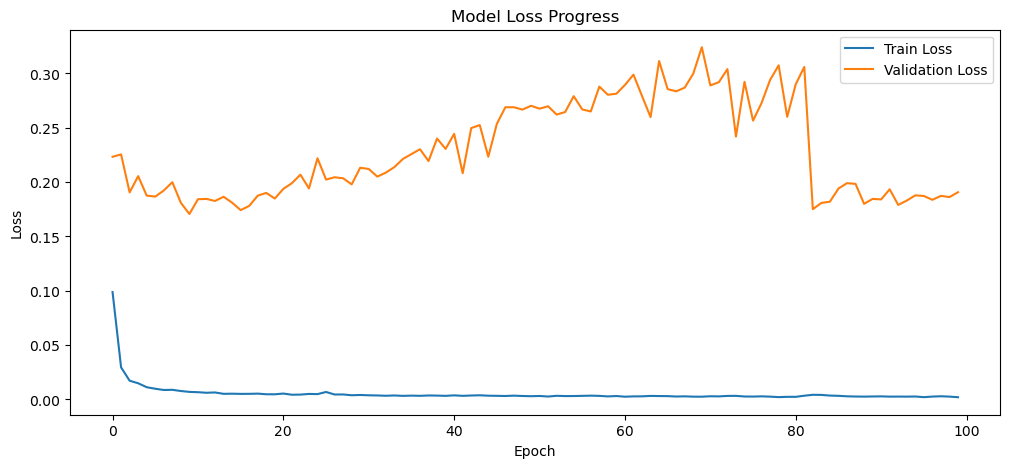

In [65]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss Progress')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()
plt.show()

In [66]:
data_train

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Beras Premium,2022-01-01,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,1,1,2022
1,Beras Premium,2022-01-02,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,2,1,2022
2,Beras Premium,2022-01-03,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,3,1,2022
3,Beras Premium,2022-01-04,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,4,1,2022
4,Beras Premium,2022-01-05,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,5,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,Beras Premium,2023-12-27,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,27,12,2023
726,Beras Premium,2023-12-28,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,28,12,2023
727,Beras Premium,2023-12-29,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,29,12,2023
728,Beras Premium,2023-12-30,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,30,12,2023


In [67]:
feature_columns = [
    'harga_petani_scaled', 
    'harga_pengecer_scaled', 
    'luas_panen_scaled', 
    'produktivitas_scaled', 
    'produksi_scaled',       # sudah dinormalisasi
    'hari_sin',
    'hari_cos',
    'bulan_sin',
    'bulan_cos',
    'tahun_norm'
]

In [68]:
fitur_pred=[
    'Tanggal',
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Hari',
    'Bulan',
    'Tahun'
]

In [69]:
fitur_predx=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
    'Hari',
    'Bulan',
    'Tahun'
]

In [70]:
fitur_predy=[
    'Harga Petani',
    'Harga Pengecer',
    'Luas Panen',
    'Produktivitas',
    'Produksi',
]

In [71]:
sample_data_predict=data_train[fitur_pred].tail(60)
sample_data_predict.reset_index(drop=True, inplace=True)
sample_data_predict

,Tanggal,Harga Petani,Harga Pengecer,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,2023-11-02,13500.000000,14500.000000,8101.2824,54.176608,43890.0,2,11,2023
1,2023-11-03,13500.000000,14500.000000,8101.2824,54.176608,43890.0,3,11,2023
2,2023-11-04,13445.205562,14623.888309,8101.2824,54.176608,43890.0,4,11,2023
3,2023-11-05,13182.229489,14616.611792,8101.2824,54.176608,43890.0,5,11,2023
4,2023-11-06,13500.000000,14600.000000,8101.2824,54.176608,43890.0,6,11,2023
5,2023-11-07,13500.000000,14600.000000,8101.2824,54.176608,43890.0,7,11,2023
6,2023-11-08,13500.000000,14600.000000,8101.2824,54.176608,43890.0,8,11,2023
7,2023-11-09,13500.000000,14600.000000,8101.2824,54.176608,43890.0,9,11,2023
8,2023-11-10,13500.000000,14600.000000,8101.2824,54.176608,43890.0,10,11,2023
9,2023-11-11,13360.091350,14600.862474,8101.2824,54.176608,43890.0,11,11,2023


In [72]:
sample_data_predict.set_index('Tanggal', inplace=True)

# Deployment Prediksi

In [74]:
from sklearn.model_selection import TimeSeriesSplit

In [75]:
tscv = TimeSeriesSplit(n_splits=5)

In [77]:
data_sample=data_train.copy()

In [78]:
num_scale=data_sample[kolom_scale]

In [79]:
num_data = scaler.transform(num_scale.to_numpy())
nama_kolom_scaled_baru = ['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled', 'produktivitas_scaled', 'produksi_scaled']
scaled_num = pd.DataFrame(num_data, columns=nama_kolom_scaled_baru)
scaled_num

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled
0,0.000021,0.122205,1.000000,0.204491,1.000000
1,0.000021,0.122205,1.000000,0.204491,1.000000
2,0.000021,0.122205,1.000000,0.204491,1.000000
3,0.000021,0.122205,1.000000,0.204491,1.000000
4,0.000021,0.122205,1.000000,0.204491,1.000000
...,...,...,...,...,...
725,2.674263,2.205426,0.038288,-0.022831,0.033388
726,2.674263,2.205426,0.038288,-0.022831,0.033388
727,2.674263,2.205426,0.038288,-0.022831,0.033388
728,2.674263,2.205426,0.038288,-0.022831,0.033388


In [80]:
data_sample[nama_kolom_scaled_baru]=scaled_num

In [81]:
data_sample['hari_sin'] = np.sin(2 * np.pi * data_sample['Hari']/7)
data_sample['hari_cos'] = np.cos(2 * np.pi * data_sample['Hari']/7)
data_sample['bulan_sin'] = np.sin(2 * np.pi * data_sample['Bulan']/12)
data_sample['bulan_cos'] = np.cos(2 * np.pi * data_sample['Bulan']/12)

In [82]:
tahun_min = data_sample['Tahun'].min()
tahun_max = data_sample['Tahun'].max()
data_sample['tahun_norm'] = (data_sample['Tahun'] - tahun_min) / (tahun_max - tahun_min)

In [83]:
data_sample=data_sample.set_index('Tanggal')

In [84]:
data_sample

,Komoditi,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,...,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
Tanggal,,,,,,,,,,,,,,,,,,,,,
2022-01-01,Beras Premium,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,1,...,0.000021,0.122205,1.000000,0.204491,1.000000,7.818315e-01,0.623490,5.000000e-01,0.866025,0.0
2022-01-02,Beras Premium,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,2,...,0.000021,0.122205,1.000000,0.204491,1.000000,9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
2022-01-03,Beras Premium,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,3,...,0.000021,0.122205,1.000000,0.204491,1.000000,4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-04,Beras Premium,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,4,...,0.000021,0.122205,1.000000,0.204491,1.000000,-4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-05,Beras Premium,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,5,...,0.000021,0.122205,1.000000,0.204491,1.000000,-9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-12-27,Beras Premium,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,27,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0
2023-12-28,Beras Premium,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,28,...,2.674263,2.205426,0.038288,-0.022831,0.033388,-9.797174e-16,1.000000,-2.449294e-16,1.000000,1.0
2023-12-29,Beras Premium,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,29,...,2.674263,2.205426,0.038288,-0.022831,0.033388,7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0


In [85]:
scaled_data=data_sample[feature_columns]
scaled_data.isnull().sum()
scaled_data.columns

Index(['harga_petani_scaled', 'harga_pengecer_scaled', 'luas_panen_scaled',
       'produktivitas_scaled', 'produksi_scaled', 'hari_sin', 'hari_cos',
       'bulan_sin', 'bulan_cos', 'tahun_norm'],
      dtype='object')

In [86]:
scaled_data

,harga_petani_scaled,harga_pengecer_scaled,luas_panen_scaled,produktivitas_scaled,produksi_scaled,hari_sin,hari_cos,bulan_sin,bulan_cos,tahun_norm
Tanggal,,,,,,,,,,
2022-01-01,0.000021,0.122205,1.000000,0.204491,1.000000,7.818315e-01,0.623490,5.000000e-01,0.866025,0.0
2022-01-02,0.000021,0.122205,1.000000,0.204491,1.000000,9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
2022-01-03,0.000021,0.122205,1.000000,0.204491,1.000000,4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-04,0.000021,0.122205,1.000000,0.204491,1.000000,-4.338837e-01,-0.900969,5.000000e-01,0.866025,0.0
2022-01-05,0.000021,0.122205,1.000000,0.204491,1.000000,-9.749279e-01,-0.222521,5.000000e-01,0.866025,0.0
...,...,...,...,...,...,...,...,...,...,...
2023-12-27,2.674263,2.205426,0.038288,-0.022831,0.033388,-7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0
2023-12-28,2.674263,2.205426,0.038288,-0.022831,0.033388,-9.797174e-16,1.000000,-2.449294e-16,1.000000,1.0
2023-12-29,2.674263,2.205426,0.038288,-0.022831,0.033388,7.818315e-01,0.623490,-2.449294e-16,1.000000,1.0


In [87]:
df

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode,tahun,Luas Panen,Produktivitas,Produksi,Hari,Bulan,Tahun
0,Beras Premium,2022-01-01,9499.999998,9999.999978,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,1,1,2022
1,Beras Premium,2022-01-02,9499.999998,9999.999959,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,2,1,2022
2,Beras Premium,2022-01-03,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,3,1,2022
3,Beras Premium,2022-01-04,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,4,1,2022
4,Beras Premium,2022-01-05,9500.000000,10000.000000,Padi,Q1-2022,2022.0,38556.6200,55.203588,212846.3758,5,1,2022
...,...,...,...,...,...,...,...,...,...,...,...,...,...
725,Beras Premium,2023-12-27,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,27,12,2023
726,Beras Premium,2023-12-28,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,28,12,2023
727,Beras Premium,2023-12-29,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,29,12,2023
728,Beras Premium,2023-12-30,13500.000000,14600.000000,Padi,Q3-2023,2023.0,8101.2824,54.176608,43890.0000,30,12,2023


In [88]:
data_sample.index[-1]

Timestamp('2023-12-31 00:00:00')

In [89]:
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

# 1. Siapkan data terakhir untuk prediksi
n_timesteps = 60  # Sesuaikan dengan model Anda

# Konversi scaled_data ke numpy array
if isinstance(scaled_data, pd.DataFrame):
    scaled_data_np = scaled_data.values
else:
    scaled_data_np = scaled_data

last_sequence = scaled_data_np[-n_timesteps:]
n_features = last_sequence.shape[1]  # Jumlah fitur total

# 2. Lakukan prediksi untuk N hari ke depan
days_ahead = 731
future_predictions = []

# Bentuk awal sequence untuk prediksi
current_seq = last_sequence.copy().reshape(1, n_timesteps, n_features)

for i in range(days_ahead):
    # Prediksi satu langkah ke depan
    pred_scaled = model.predict(current_seq, verbose=0)[0]  # Output: (n_output_features,)
    
    # Simpan prediksi
    future_predictions.append(pred_scaled)
    
    # Hitung tanggal prediksi untuk fitur temporal
    pred_date = data_sample.index[-1] + timedelta(days=i+1)
    
    # Hitung fitur temporal baru
    day_of_week = pred_date.weekday()
    month = pred_date.month
    year = pred_date.year
    
    # Hitung representasi siklis
    hari_sin = np.sin(2 * np.pi * day_of_week / 7)
    hari_cos = np.cos(2 * np.pi * day_of_week / 7)
    bulan_sin = np.sin(2 * np.pi * month / 12)
    bulan_cos = np.cos(2 * np.pi * month / 12)
    
    # Normalisasi tahun (gunakan min/max tahun dari data asli)
    tahun_min = data_sample.index.year.min()
    tahun_max = data_sample.index.year.max()
    tahun_norm = (year - tahun_min) / (tahun_max - tahun_min)
    
    # Gabungkan fitur prediksi dengan fitur temporal
    # Asumsikan model hanya memprediksi 5 fitur target
    full_features = np.concatenate([
        pred_scaled[:5],  # 5 fitur target
        [hari_sin, hari_cos, bulan_sin, bulan_cos, tahun_norm]  # 5 fitur temporal
    ])
    
    # Pastikan jumlah fitur sesuai
    if len(full_features) != n_features:
        # Jika tidak sesuai, sesuaikan dengan padding
        full_features = np.pad(
            full_features, 
            (0, n_features - len(full_features)), 
            'constant',
            constant_values=0
        )
    
    # Update sequence
    current_seq = np.concatenate([
        current_seq[:, 1:, :], 
        full_features.reshape(1, 1, n_features)
    ], axis=1)

# 3. Konversi hasil prediksi
future_predictions = np.array(future_predictions)

# 4. Denormalisasi hanya fitur target (5 fitur pertama)
future_predictions_denorm = scaler.inverse_transform(future_predictions[:, :5])

# 5. Buat DataFrame hasil prediksi
future_dates = [data_sample.index[-1] + timedelta(days=i+1) for i in range(days_ahead)]

df_predictions = pd.DataFrame({
    'Tanggal': future_dates,
    'harga_petani_pred': future_predictions_denorm[:, 0],
    'harga_pengecer_pred': future_predictions_denorm[:, 1],
    'luas_lahan_pred': future_predictions_denorm[:, 2],
    'produktivitas_pred': future_predictions_denorm[:, 3],
    'produksi_pred': future_predictions_denorm[:, 4]
})

# 6. Tambahkan informasi tambahan
df_predictions['hari'] = df_predictions['Tanggal'].dt.day_name()
df_predictions['bulan'] = df_predictions['Tanggal'].dt.month_name()
df_predictions['tahun'] = df_predictions['Tanggal'].dt.year

print("Hasil Prediksi:")
print(df_predictions.head())

Hasil Prediksi:
     Tanggal  harga_petani_pred  harga_pengecer_pred  luas_lahan_pred  \
0 2024-01-01       10304.972656         11705.167969     26819.111328   
1 2024-01-02       10257.424805         11614.534180     26653.292969   
2 2024-01-03       10209.408203         11524.829102     26502.716797   
3 2024-01-04       10172.836914         11460.847656     26466.765625   
4 2024-01-05       10149.465820         11423.054688     26586.839844   

   produktivitas_pred  produksi_pred       hari    bulan  tahun  
0           55.246929  139726.671875     Monday  January   2024  
1           55.245914  140572.265625    Tuesday  January   2024  
2           55.233952  140917.015625  Wednesday  January   2024  
3           55.224190  141530.546875   Thursday  January   2024  
4           55.222984  142930.781250     Friday  January   2024  


In [90]:
df_predictions

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun
0,2024-01-01,10304.972656,11705.167969,26819.111328,55.246929,139726.671875,Monday,January,2024
1,2024-01-02,10257.424805,11614.534180,26653.292969,55.245914,140572.265625,Tuesday,January,2024
2,2024-01-03,10209.408203,11524.829102,26502.716797,55.233952,140917.015625,Wednesday,January,2024
3,2024-01-04,10172.836914,11460.847656,26466.765625,55.224190,141530.546875,Thursday,January,2024
4,2024-01-05,10149.465820,11423.054688,26586.839844,55.222984,142930.781250,Friday,January,2024
...,...,...,...,...,...,...,...,...,...
726,2025-12-27,10145.297852,11487.648438,31188.320312,55.457058,177389.656250,Saturday,December,2025
727,2025-12-28,10151.720703,11496.716797,31421.554688,55.464977,178529.843750,Sunday,December,2025
728,2025-12-29,10156.051758,11502.443359,31631.955078,55.470451,179644.125000,Monday,December,2025
729,2025-12-30,10154.617188,11499.316406,31655.361328,55.469830,179843.218750,Tuesday,December,2025


In [91]:
hasil_prediksi_2025='/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga premium_2025.csv'


In [92]:
df_predictions.to_csv(hasil_prediksi_2025, index=False)
print(f"DataFrame prediksi berhasil disimpan ke '{hasil_prediksi_2025}'")

DataFrame prediksi berhasil disimpan ke '/home/rna_13/ModelPredict/Data Prediksi/2025/Data Prediksi Harga premium_2025.csv'


In [93]:
def calculate_mape(actual, predicted):
    actual, predicted = np.array(actual), np.array(predicted)
    return np.mean(np.abs((actual - predicted) / actual)) * 100

In [94]:
df_aktual = df_harga[(df_harga['Tanggal'] >= '2024-01-01') & (df_harga['Tanggal'] <= '2024-12-31')].copy()

In [95]:
df_aktual

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
730,Beras Premium,2024-01-01,<NA>,<NA>,Padi,Q1-2024
731,Beras Premium,2024-01-02,13500,14600,Padi,Q1-2024
732,Beras Premium,2024-01-03,13500,14600,Padi,Q1-2024
733,Beras Premium,2024-01-04,13500,14600,Padi,Q1-2024
734,Beras Premium,2024-01-05,13500,14600,Padi,Q1-2024
...,...,...,...,...,...,...
1091,Beras Premium,2024-12-27,13000,14000,Padi,Q3-2024
1092,Beras Premium,2024-12-28,13000,14000,Padi,Q3-2024
1093,Beras Premium,2024-12-29,13000,14000,Padi,Q3-2024
1094,Beras Premium,2024-12-30,<NA>,<NA>,Padi,Q3-2024


In [96]:
df_aktual=df_aktual.reset_index()
df_aktual=df_aktual.drop(columns=['index'])
df_aktual

,Komoditi,Tanggal,Harga Petani,Harga Pengecer,Tipe,Periode
0,Beras Premium,2024-01-01,<NA>,<NA>,Padi,Q1-2024
1,Beras Premium,2024-01-02,13500,14600,Padi,Q1-2024
2,Beras Premium,2024-01-03,13500,14600,Padi,Q1-2024
3,Beras Premium,2024-01-04,13500,14600,Padi,Q1-2024
4,Beras Premium,2024-01-05,13500,14600,Padi,Q1-2024
...,...,...,...,...,...,...
361,Beras Premium,2024-12-27,13000,14000,Padi,Q3-2024
362,Beras Premium,2024-12-28,13000,14000,Padi,Q3-2024
363,Beras Premium,2024-12-29,13000,14000,Padi,Q3-2024
364,Beras Premium,2024-12-30,<NA>,<NA>,Padi,Q3-2024


In [97]:
kolom_harga=[
    'Tanggal',
    'Harga Petani', 
    'Harga Pengecer'
]

In [98]:
df_aktual = df_aktual[kolom_harga]

In [99]:
df_aktual

,Tanggal,Harga Petani,Harga Pengecer
0,2024-01-01,<NA>,<NA>
1,2024-01-02,13500,14600
2,2024-01-03,13500,14600
3,2024-01-04,13500,14600
4,2024-01-05,13500,14600
...,...,...,...
361,2024-12-27,13000,14000
362,2024-12-28,13000,14000
363,2024-12-29,13000,14000
364,2024-12-30,<NA>,<NA>


In [100]:
print("DataFrame sebelum imputasi:")
print(df_aktual)
print("\nMissing values sebelum imputasi:")
print(df_aktual['Harga Petani'].isnull().sum())
print(df_aktual['Harga Pengecer'].isnull().sum())


# Pastikan kolom 'Tanggal' adalah indeks

# Terapkan fungsi stl_imputation ke kolom 'Harga Petani'
# Karena STL bekerja per seri waktu, Anda harus menerapkan ini per komoditi jika Anda memiliki banyak komoditi.
# Jika Anda ingin menerapkan per komoditas, Anda harus mengulanginya:

# Untuk satu komoditi (seperti dalam contoh df saat ini):
df_aktual['Harga Petani'] = stl_imputation(df['Harga Petani'], period=30) # Asumsi periode bulanan
df_aktual['Harga Pengecer'] = stl_imputation(df['Harga Pengecer'], period=30)


print("\nDataFrame setelah imputasi:")
print(df_aktual)
print("\nMissing values setelah imputasi:")
print(df_aktual['Harga Petani'].isnull().sum())
print(df_aktual['Harga Pengecer'].isnull().sum())

DataFrame sebelum imputasi:
       Tanggal Harga Petani Harga Pengecer
0   2024-01-01         <NA>           <NA>
1   2024-01-02        13500          14600
2   2024-01-03        13500          14600
3   2024-01-04        13500          14600
4   2024-01-05        13500          14600
..         ...          ...            ...
361 2024-12-27        13000          14000
362 2024-12-28        13000          14000
363 2024-12-29        13000          14000
364 2024-12-30         <NA>           <NA>
365 2024-12-31         <NA>           <NA>

[366 rows x 3 columns]

Missing values sebelum imputasi:
114
114
Tidak ada missing value untuk diisi.
Tidak ada missing value untuk diisi.

DataFrame setelah imputasi:
       Tanggal  Harga Petani  Harga Pengecer
0   2024-01-01   9499.999998     9999.999978
1   2024-01-02   9499.999998     9999.999959
2   2024-01-03   9500.000000    10000.000000
3   2024-01-04   9500.000000    10000.000000
4   2024-01-05   9500.000000    10000.000000
..         ...   

In [101]:
df_aktual=df_aktual.to_pandas()
df_aktual

,Tanggal,Harga Petani,Harga Pengecer
0,2024-01-01,9499.999998,9999.999978
1,2024-01-02,9499.999998,9999.999959
2,2024-01-03,9500.000000,10000.000000
3,2024-01-04,9500.000000,10000.000000
4,2024-01-05,9500.000000,10000.000000
...,...,...,...
361,2024-12-27,9600.000000,10000.000000
362,2024-12-28,9600.000000,10000.000000
363,2024-12-29,9600.000000,10000.000000
364,2024-12-30,9741.391657,10649.043007


In [102]:
def calculate_rmse(y_actual, y_predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between actual and predicted values.

    Args:
        y_actual (numpy.array or list): The true/actual values.
        y_predicted (numpy.array or list): The predicted values.

    Returns:
        float: The calculated RMSE value.
    """
    y_actual = np.array(y_actual)
    y_predicted = np.array(y_predicted)

    mse = np.mean((y_actual - y_predicted)**2)
    rmse = np.sqrt(mse)
    return rmse

In [103]:

# Menggabungkan DataFrame prediksi dan aktual
df_combined = pd.merge(df_predictions, df_aktual, on='Tanggal')


# Hitung MAPE untuk harga
mape_harga = calculate_mape(df_combined['Harga Petani'], df_combined['harga_petani_pred'])
print(f"MAPE untuk harga: {mape_harga:.2f}%")

rmse_value = calculate_rmse(df_combined['Harga Petani'], df_combined['harga_petani_pred'])
print(f"RMSE: {rmse_value}")


MAPE untuk harga: 5.64%
RMSE: 543.3997010258113


In [104]:
df_combined

,Tanggal,harga_petani_pred,harga_pengecer_pred,luas_lahan_pred,produktivitas_pred,produksi_pred,hari,bulan,tahun,Harga Petani,Harga Pengecer
0,2024-01-01,10304.972656,11705.167969,26819.111328,55.246929,139726.671875,Monday,January,2024,9499.999998,9999.999978
1,2024-01-02,10257.424805,11614.534180,26653.292969,55.245914,140572.265625,Tuesday,January,2024,9499.999998,9999.999959
2,2024-01-03,10209.408203,11524.829102,26502.716797,55.233952,140917.015625,Wednesday,January,2024,9500.000000,10000.000000
3,2024-01-04,10172.836914,11460.847656,26466.765625,55.224190,141530.546875,Thursday,January,2024,9500.000000,10000.000000
4,2024-01-05,10149.465820,11423.054688,26586.839844,55.222984,142930.781250,Friday,January,2024,9500.000000,10000.000000
...,...,...,...,...,...,...,...,...,...,...,...
361,2024-12-27,10071.796875,11328.683594,29145.871094,55.342388,165591.921875,Friday,December,2024,9600.000000,10000.000000
362,2024-12-28,10073.395508,11329.881836,29185.554688,55.343201,165859.578125,Saturday,December,2024,9600.000000,10000.000000
363,2024-12-29,10079.894531,11340.459961,29340.814453,55.347950,166779.531250,Sunday,December,2024,9600.000000,10000.000000
364,2024-12-30,10081.963867,11342.050781,29465.716797,55.348942,167532.859375,Monday,December,2024,9741.391657,10649.043007


In [105]:
df_combined_harga_petani=df_combined[['harga_petani_pred', 'Harga Petani']]

In [106]:
df_combined_harga_petani

,harga_petani_pred,Harga Petani
0,10304.972656,9499.999998
1,10257.424805,9499.999998
2,10209.408203,9500.000000
3,10172.836914,9500.000000
4,10149.465820,9500.000000
...,...,...
361,10071.796875,9600.000000
362,10073.395508,9600.000000
363,10079.894531,9600.000000
364,10081.963867,9741.391657


# Menyimpan Model

In [107]:
model_path='ModelBerasPremium_temp.keras'

In [108]:
try:
    model.save(model_path)
    print(f"Model berhasil disimpan di: {model_path}")
except Exception as e:
    print(f"Gagal menyimpan model: {e}")

Model berhasil disimpan di: ModelBerasPremium_temp.keras


In [109]:
hasil_prediksi='Data Prediksi Harga Beras Premium_temp.csv'
data_bahan_prediksi_normalisasi='Data Beras Premium Normalisasi_temp.csv'

In [110]:
df_combined.to_csv(hasil_prediksi, index=False)
print(f"DataFrame prediksi berhasil disimpan ke '{hasil_prediksi}'")


DataFrame prediksi berhasil disimpan ke 'Data Prediksi Harga Beras Premium_temp.csv'


In [111]:
data_sample.to_csv(data_bahan_prediksi_normalisasi)
print(f"DataFrame normalisasi beras berhasil disimpan ke '{data_bahan_prediksi_normalisasi}'")

DataFrame normalisasi beras berhasil disimpan ke 'Data Beras Premium Normalisasi_temp.csv'


In [112]:
from sklearn.preprocessing import MinMaxScaler
import joblib


# Simpan scaler ke file
joblib.dump(scaler, 'scaler_beras_premium_temp.pkl')


['scaler_beras_premium_temp.pkl']